Columns: Index(['Name', 'Status', 'District', 'Population\nCensus\n1991-03-01',
       'Population\nCensus\n2001-03-01', 'Population\nCensus\n2011-03-01'],
      dtype='str')
Cleaned Data Shape: (1096, 6)
           city          status        district  pop_1991  pop_2001  pop_2011
0      Abiramam  Town Panchayat  Ramanathapuram       NaN    6638.0      8144
1  Acharapakkam  Town Panchayat     Kanchipuram       NaN    9023.0     10362
2     Achipatti     Census Town      Coimbatore       NaN    7448.0      9849
3  Adaikkakuzhi     Census Town   Kanniyakumari       NaN       NaN      8888
4    Adikaratti  Town Panchayat    The Nilgiris       NaN   16003.0     14178

Top Cities:
                 city         district  pop_2011
128  Chennai [Madras]          Chennai   4646732
156        Coimbatore       Coimbatore   1050721
432           Madurai          Madurai   1017865
952   Tiruchirappalli  Tiruchirappalli    847387
775             Salem            Salem    829267
956       Tirunelvel

<Figure size 640x480 with 0 Axes>

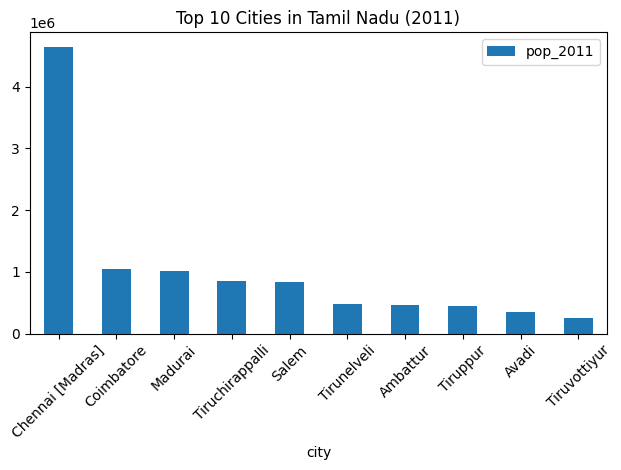

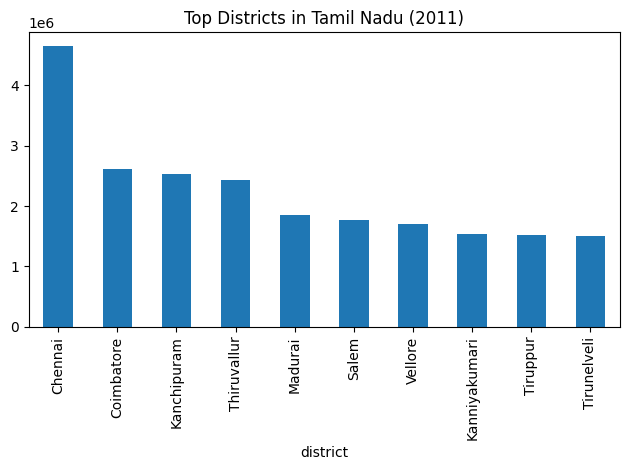

<Figure size 640x480 with 0 Axes>

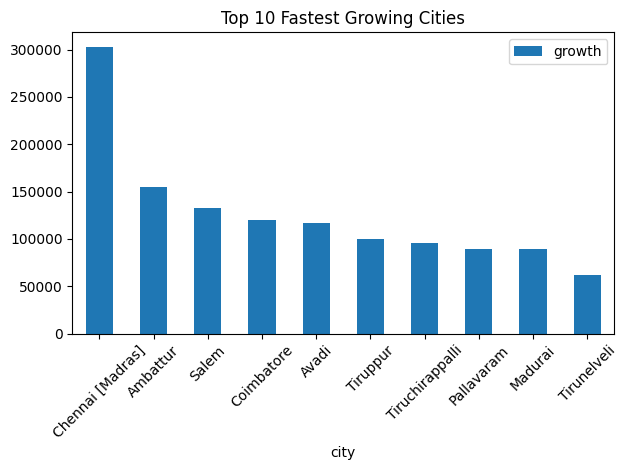

Map saved as tn_map.html
Heatmap saved as tn_heatmap.html

All tasks completed successfully!


In [2]:
# Spatial & Geospatial Analysis
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

# ================================
# STEP 1: LOAD DATA
# ================================
df = pd.read_csv("TN_Population_Statistics.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns)

# Rename properly
df.rename(columns={
    df.columns[0]: "city",
    df.columns[1]: "status",
    df.columns[2]: "district",
    df.columns[3]: "pop_1991",
    df.columns[4]: "pop_2001",
    df.columns[5]: "pop_2011"
}, inplace=True)

# ================================
# STEP 2: CLEAN DATA
# ================================

# Remove commas and invalid values
for col in ["pop_1991", "pop_2001", "pop_2011"]:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace(",", "")
    df[col] = df[col].str.replace("...", "")  # remove dots
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where 2011 population is missing
df = df.dropna(subset=["pop_2011"])

print("Cleaned Data Shape:", df.shape)
print(df.head())

# ================================
# STEP 3: INSIGHTS
# ================================
df["growth"] = df["pop_2011"] - df["pop_2001"]

# ================================
# STEP 4: TOP CITIES
# ================================
top_cities = df.sort_values(by="pop_2011", ascending=False).head(10)

print("\nTop Cities:")
print(top_cities[["city", "district", "pop_2011"]])

# ================================
# STEP 5: BAR CHART
# ================================
if not top_cities.empty:
    plt.figure()
    top_cities.plot(
        x="city",
        y="pop_2011",
        kind="bar",
        title="Top 10 Cities in Tamil Nadu (2011)"
    )
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No data for plotting")

# ================================
# STEP 6: DISTRICT ANALYSIS
# ================================
district_pop = df.groupby("district")["pop_2011"].sum().sort_values(ascending=False)

plt.figure()
district_pop.head(10).plot(kind="bar", title="Top Districts in Tamil Nadu (2011)")
plt.tight_layout()
plt.show()

# ================================
# STEP 6B: GROWTH ANALYSIS
# ================================

top_growth = df.sort_values(by="growth", ascending=False).head(10)

plt.figure()
top_growth.plot(
    x="city",
    y="growth",
    kind="bar",
    title="Top 10 Fastest Growing Cities"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ================================
# STEP 7: SIMPLE MAP (NO GEOPY)
# ================================

# Manual coordinates (important cities)
coords = {
    "Chennai": [13.0827, 80.2707],
    "Coimbatore": [11.0168, 76.9558],
    "Madurai": [9.9252, 78.1198],
    "Tiruchirappalli": [10.7905, 78.7047],
    "Salem": [11.6643, 78.1460],
    "Erode": [11.3410, 77.7172],
    "Tiruppur": [11.1085, 77.3411],
    "Vellore": [12.9165, 79.1325],
    "Thoothukudi": [8.7642, 78.1348],
    "Dindigul": [10.3673, 77.9803]
}

map_tn = folium.Map(location=[11.1271, 78.6569], zoom_start=7)

for _, row in top_cities.iterrows():
    city = row["city"]
    if city in coords:
        folium.Marker(
            location=coords[city],
            popup=f"{city}: {int(row['pop_2011'])}"
        ).add_to(map_tn)

map_tn.save("tn_map.html")

print("Map saved as tn_map.html")

# ================================
# STEP 8: HEATMAP
# ================================
# heat_data = list(coords.values())
heat_data = []

for _, row in df.iterrows():
    city = row["city"]
    if city in coords:
        lat, lon = coords[city]
        weight = row["pop_2011"] / 100000  # normalize
        heat_data.append([lat, lon, weight])


map_heat = folium.Map(location=[11.1271, 78.6569], zoom_start=7)
HeatMap(heat_data).add_to(map_heat)

map_heat.save("tn_heatmap.html")

print("Heatmap saved as tn_heatmap.html")

# ================================
# DONE
# ================================
print("\nAll tasks completed successfully!")

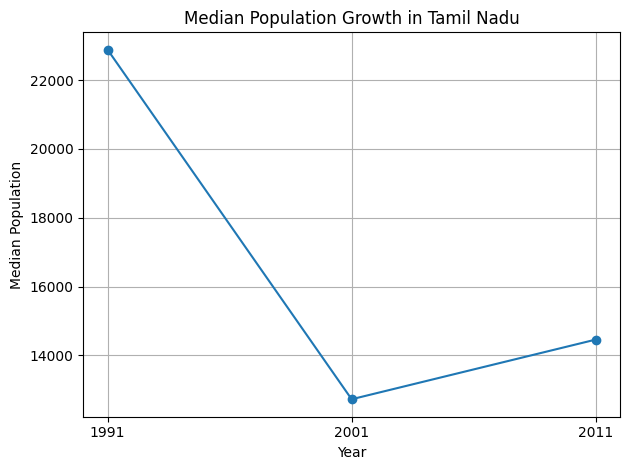

In [8]:
# ================================
# LINE CHART – MEDIAN POPULATION
# ================================

median_pop = [
    df["pop_1991"].median(),
    df["pop_2001"].median(),
    df["pop_2011"].median()
]

years = ["1991", "2001", "2011"]

plt.figure()
plt.plot(years, median_pop, marker='o')

plt.title("Median Population Growth in Tamil Nadu")
plt.xlabel("Year")
plt.ylabel("Median Population")
plt.grid()

plt.tight_layout()
plt.show()